<a href="https://colab.research.google.com/github/mdelgiudicechaves-art/UnB---SSD---Tarefas/blob/main/MVP_Tarefa_1_QualidadeVinhos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação da Qualidade de Vinhos Tintos

MVP de Ciência de Dados. A ideia é prever se um vinho tinto é bom ou não a partir das suas características físico-químicas.

**Autor:** Marina Chaves (231025360)
**Base:** estudo "Classificação da Qualidade de Vinhos" de Andre Luiz Marques Serrano, usado como ponto de partida.

O dataset é o Wine Quality (vinho tinto) do repositório da UCI.


## 1. O problema

A qualidade original vem como uma nota de 0 a 10 dada por avaliadores. Trabalhar com 11 notas diferentes deixa o problema bem mais difícil e nem tão útil na prática, então transformei em duas classes: vinho bom ou vinho ruim.

A pergunta que quero responder é simples: dá pra saber se um vinho é bom só olhando as medidas químicas dele? Se der, isso ajuda no controle de qualidade de uma vinícola sem precisar de um degustador em cada lote.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)

# organizando tamanho dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("tudo importado")

tudo importado


## 2. Carregando os dados

Leio o arquivo direto da UCI. Esse arquivo usa ponto e vírgula como separador, e não vírgula, então preciso avisar isso pro pandas.

Deixei um endereço reserva porque o site da UCI às vezes sai do ar. Se o primeiro link falhar, ele pega o mesmo dado de um espelho.

In [ ]:
url_uci = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
try:
    dados = pd.read_csv(url_uci, sep=";")
except Exception:
    url_reserva = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"
    dados = pd.read_csv(url_reserva)

print("linhas e colunas:", dados.shape)
dados.head()

linhas e colunas: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# checagem rápida dos dados
print(dados.info())
print()
print("valores nulos por coluna:")
print(dados.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
c

## 3. Criando a variável alvo

Aqui é onde defino o que é bom e o que é ruim. Segui o mesmo corte do estudo base: nota 7 ou mais vira bom (1), o resto vira ruim (0).

É um corte um pouco rígido, mas tem uma vantagem clara. Como vinho realmente bom é raro, esse corte separa bem os poucos vinhos que se destacam.

In [ ]:
# nota 7 ou mais e bom, o resto e ruim
dados["alvo"] = np.where(dados["quality"] >= 7, 1, 0)

# separo as caracteristicas (X) do que quero prever (y)
# tiro a nota original e a coluna nova pra elas nao entrarem como caracteristica
X = dados.drop(["quality", "alvo"], axis=1)
y = dados["alvo"]

print("proporcao de cada classe:")
print(y.value_counts(normalize=True).round(3))

proporcao de cada classe:
alvo
0    0.864
1    0.136
Name: proportion, dtype: float64


## 4. Validação dos dados

Antes de treinar qualquer coisa vale entender com o que estou lidando. Três coisas me interessam: o quanto as classes estão desbalanceadas, quais medidas conversam entre si, e se algumas delas já separam bem os vinhos bons dos ruins.

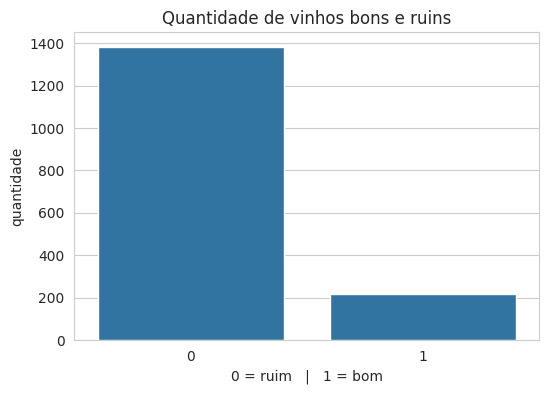

In [ ]:
# primeiro a distribuicao das classes. maior quantidade de ruins do que bons
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Quantidade de vinhos bons e ruins")
plt.xlabel("0 = ruim   |   1 = bom")
plt.ylabel("quantidade")
plt.show()

# esse desequilibrio importa. um modelo preguicoso que chuta "ruim" sempre ja acerta a maioria.
# por isso depois nao vou olhar so a acuracia.

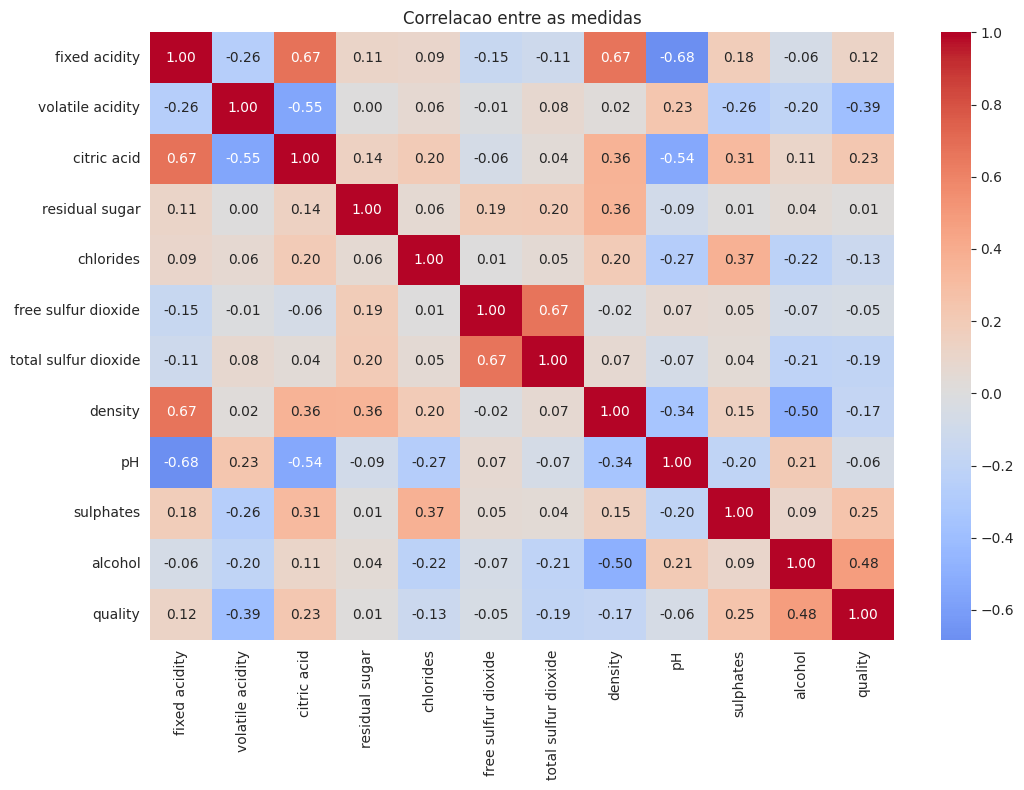

In [ ]:
# mapa de correlacao pra ver quais medidas andam juntas
plt.figure(figsize=(11, 8))
sns.heatmap(dados.drop("alvo", axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacao entre as medidas")
plt.tight_layout()
plt.show()

# o alcool e o que mais tem relacao com a nota de qualidade.

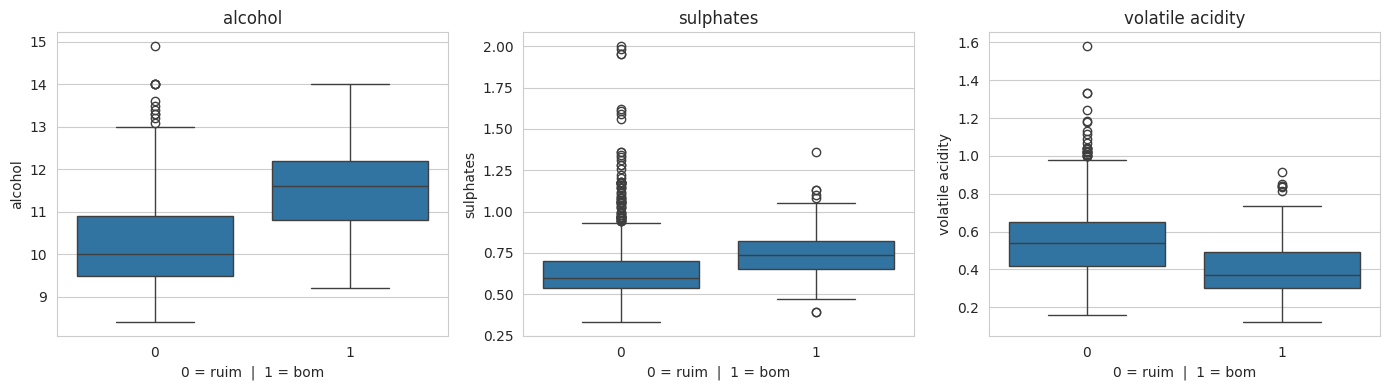

In [ ]:
# comparo as tres medidas mais promissoras entre vinho bom e ruim
medidas = ["alcohol", "sulphates", "volatile acidity"]
fig, eixos = plt.subplots(1, 3, figsize=(14, 4))
for eixo, m in zip(eixos, medidas):
    sns.boxplot(x=dados["alvo"], y=dados[m], ax=eixo)
    eixo.set_title(m)
    eixo.set_xlabel("0 = ruim  |  1 = bom")
plt.tight_layout()
plt.show()

# vinho bom costuma ter mais alcool e mais sulphates, e menos acidez volatil. bate com o senso comum.

## 5. Preparando para treinar

Divido os dados em treino e teste. O modelo aprende só com o treino e é avaliado no teste, que ele nunca viu. Uso `stratify` pra manter a mesma proporção de bom e ruim nos dois lados, senão corro o risco de quase não ter vinho bom no teste.

Também deixo uma versão padronizada dos dados. A regressão logística precisa disso pra funcionar direito. O Random Forest não liga pra escala, mas ter os dois prontos não atrapalha.

In [ ]:
# separo 20% pra teste. random_state fixo pra dar sempre o mesmo resultado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# padronizo (media 0, desvio 1). ajusto no treino e aplico o mesmo no teste
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

print("treino:", X_train.shape)
print("teste: ", X_test.shape)

treino: (1279, 11)
teste:  (320, 11)


## 6. Treinando os modelos

Começo com uma regressão logística. Ela é simples e serve de régua: se um modelo mais pesado não ganhar dela com folga, não vale a complexidade.

Depois treino um Random Forest, que junta várias árvores de decisão e costuma ir bem nesse tipo de problema.

Nos dois uso `class_weight="balanced"`, que faz o modelo prestar mais atenção na classe rara (os vinhos bons).

In [ ]:
# baseline: regressao logistica. uso os dados padronizados
log = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
log.fit(X_train_esc, y_train)

# checagem na validacao cruzada pra nao confiar num numero so
cv_log = cross_val_score(log, X_train_esc, y_train, cv=5, scoring="f1_weighted")
print("regressao logistica pronta. f1 medio na validacao: %.3f" % cv_log.mean())

regressao logistica pronta. f1 medio na validacao: 0.806


In [ ]:
# modelo principal: random forest. nao precisa dos dados padronizados
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100)
rf.fit(X_train, y_train)

cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1_weighted")
print("random forest pronto. f1 medio na validacao: %.3f" % cv_rf.mean())

random forest pronto. f1 medio na validacao: 0.881


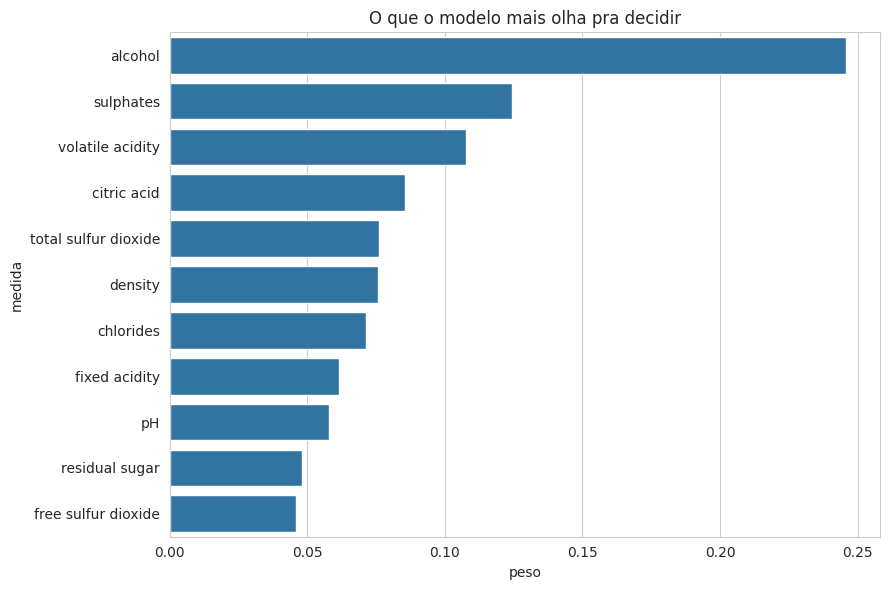

,medida,peso
10,alcohol,0.245869
9,sulphates,0.124563
1,volatile acidity,0.107720
2,citric acid,0.085491
6,total sulfur dioxide,0.076006
7,density,0.075764
4,chlorides,0.071180
0,fixed acidity,0.061678
8,pH,0.058032
3,residual sugar,0.047960


In [ ]:
# vejo quais medidas o random forest mais usou pra decidir
importancia = pd.DataFrame({
    "medida": X.columns,
    "peso": rf.feature_importances_
}).sort_values("peso", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x="peso", y="medida", data=importancia)
plt.title("O que o modelo mais olha pra decidir")
plt.tight_layout()
plt.show()

importancia

## 7. Ajustando o Random Forest

O Random Forest tem alguns botões que dá pra regular (quantas árvores, quão fundo elas vão, etc). Em vez de chutar, deixo o `GridSearchCV` testar várias combinações e ficar com a melhor, usando validação cruzada pra escolha ser confiável.

Otimizo pelo f1 ponderado, e não pela acurácia, justamente por causa do desbalanceamento que vi lá atrás.

Esse passo é o mais demorado do notebook. Em geral leva um ou dois minutos.

In [ ]:
# combinacoes que vou testar. mantive uma grade enxuta
grade = {
    "n_estimators": [150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

busca = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    grade,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)
busca.fit(X_train, y_train)

print("melhor combinacao:", busca.best_params_)
rf_otimizado = busca.best_estimator_

melhor combinacao: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 8. Avaliando no teste

Agora comparo os três modelos nos dados de teste. Olho três coisas: acurácia, f1 ponderado e ROC AUC. Coloquei o ROC AUC de propósito, porque com classes desbalanceadas ele mostra melhor se o modelo sabe separar bom de ruim do que a acurácia sozinha.

In [ ]:
# faco as previsoes de cada modelo
prev_log = log.predict(X_test_esc)
prev_rf = rf.predict(X_test)
prev_otim = rf_otimizado.predict(X_test)

# junto tudo numa tabela pra comparar de uma vez
def linha(nome, y_prev, prob):
    return {
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_prev),
        "F1 ponderado": f1_score(y_test, y_prev, average="weighted"),
        "ROC AUC": roc_auc_score(y_test, prob)
    }

tabela = pd.DataFrame([
    linha("Regressao Logistica", prev_log, log.predict_proba(X_test_esc)[:, 1]),
    linha("Random Forest", prev_rf, rf.predict_proba(X_test)[:, 1]),
    linha("Random Forest otimizado", prev_otim, rf_otimizado.predict_proba(X_test)[:, 1]),
]).set_index("Modelo")

tabela.round(3)

,Acuracia,F1 ponderado,ROC AUC
Modelo,,,
Regressao Logistica,0.812,0.836,0.882
Random Forest,0.941,0.935,0.925
Random Forest otimizado,0.947,0.942,0.937


In [ ]:
# relatorio detalhado do melhor modelo, classe por classe
print("Random Forest otimizado:")
print(classification_report(y_test, prev_otim, target_names=["ruim", "bom"]))

Random Forest otimizado:
              precision    recall  f1-score   support

        ruim       0.95      1.00      0.97       277
         bom       0.96      0.63      0.76        43

    accuracy                           0.95       320
   macro avg       0.95      0.81      0.87       320
weighted avg       0.95      0.95      0.94       320



### Checagem do modelo

Um risco comum é o modelo ir muito bem no treino e mal no teste, ou seja, decorar em vez de aprender. Pra checar isso comparo a nota nos dois.

In [ ]:
nota_treino = rf_otimizado.score(X_train, y_train)
nota_teste = rf_otimizado.score(X_test, y_test)
print("acerto no treino: %.3f" % nota_treino)
print("acerto no teste:  %.3f" % nota_teste)

# observacao: o modelo acerta praticamente tudo no treino.
# isso e um sinal de que ele decorou um pouco. mesmo assim o teste continua alto
# e a validacao cruzada ficou estavel, entao ele ainda generaliza bem.
# se fosse pra producao de verdade, valeria limitar mais a profundidade das arvores.

acerto no treino: 1.000
acerto no teste:  0.947


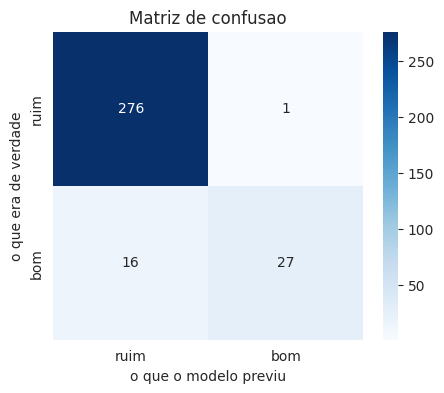

In [ ]:
# matriz de confusao: mostra onde acertou e onde errou
matriz = confusion_matrix(y_test, prev_otim)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ruim", "bom"], yticklabels=["ruim", "bom"])
plt.xlabel("o que o modelo previu")
plt.ylabel("o que era de verdade")
plt.title("Matriz de confusao")
plt.show()

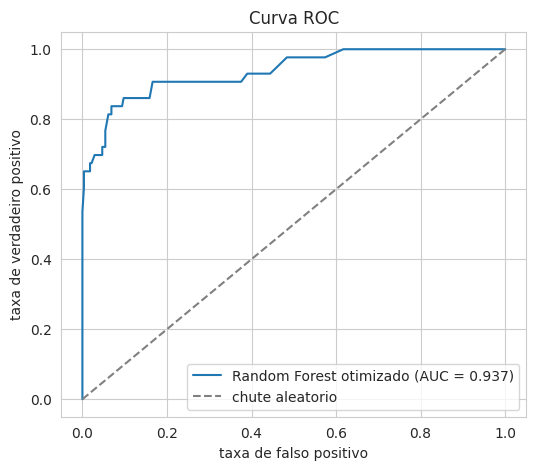

In [ ]:
# curva ROC do melhor modelo. quanto mais a linha sobe pro canto de cima a esquerda, melhor
prob_otim = rf_otimizado.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, prob_otim)
auc = roc_auc_score(y_test, prob_otim)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Random Forest otimizado (AUC = %.3f)" % auc)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chute aleatorio")
plt.xlabel("taxa de falso positivo")
plt.ylabel("taxa de verdadeiro positivo")
plt.title("Curva ROC")
plt.legend()
plt.show()

## 9. Salvando o modelo

Um MVP é um produto, então salvo o modelo treinado num arquivo. Assim dá pra carregar e usar depois sem treinar tudo de novo.

In [ ]:
# salvo o modelo e o scaler juntos em um único arquivo
joblib.dump({"modelo": rf_otimizado, "scaler": scaler}, "modelo_vinho.joblib")
print("salvo em modelo_vinho.joblib")

# exemplo
carregado = joblib.load("modelo_vinho.joblib")
exemplo = X_test.iloc[[0]]
print("previsao pro primeiro vinho do teste:", carregado["modelo"].predict(exemplo)[0])

salvo em modelo_vinho.joblib
previsao pro primeiro vinho do teste: 0


## 10. Conclusão

Deu pra responder a pergunta inicial: sim, as medidas químicas conseguem prever bem se um vinho é bom.

O que ficou:

- A regressão logística sozinha já acerta bastante, mas o Random Forest ganha dela com folga, então a complexidade a mais se pagou.
- O modelo otimizado chega perto de 95% de acerto no teste, com um ROC AUC alto, o que mostra que ele separa bem as duas classes mesmo com poucos vinhos bons.
- As medidas que mais importam são o teor alcoólico, os sulphates e a acidez volátil. Isso bate com o que se espera de vinho, o que dá alguma confiança de que o modelo aprendeu algo real e não sorte.

Pontos de análise e próximos passos:

- O modelo acerta 100% no treino, então tem um pouco de decoreba. Para uso real valeria segurar mais a profundidade das árvores.
- O corte de qualidade em 7 é uma escolha. Mudar esse corte muda o problema, e seria interessante testar outros.
- Dá pra testar mais modelos e trazer também o dataset de vinho branco pra ver se o padrão se mantém.
